# GMMainPlot: Pure-Python Plots Before the LISA Noise Model

This notebook ports the content before the **LISA noise model** section of `Mathematica/v2/GMMainPlot_v2.0.nb`. Computation depends only on `src/v2/gmlib.py` and optional `data/*.npz` caches, not on Mathematica notebooks or `.m` files. Missing caches trigger pure-Python numerical integration and are written back to `data`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import linear_sum_assignment

%matplotlib inline

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, *working_directory.parents)
    if (candidate / 'src' / 'v2' / 'gmlib.py').is_file()
)
V2_SRC = PROJECT_ROOT / 'src' / 'v2'
if str(V2_SRC) not in sys.path:
    sys.path.insert(0, str(V2_SRC))

from gmlib import (
    DataRepository, GMModel, GMParameters, IntegrationSettings,
    PLANCK_TIME_S, luminosity_distance_planck, numerical_derivative,
    plot_growth_eigensystem,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'legend.frameon': False,
})
PROJECT_ROOT

PosixPath('/global/u1/l/liuyh15/WorkSpace/GM')

## 1. Parameters and model

The next cell collects the physical and plotting parameters used by the Mathematica notebook. `q` selects the integration-table cache; `m1`, `alpha`, and `mc` enter the physical calculations after the tables are loaded.

In [2]:
# ===== User parameters: edit this cell =====
q = 0.99                # mass ratio m2 / m1
m1 = 40.0               # primary black-hole mass [solar masses]
alpha = 0.1             # gravitational fine-structure constant
mc = 0.1                 # cloud mass / m1

number = 100             # separation samples
x_start = 10.0           # R / r_b1
x_end = 38.0
evolution_samples = 2_000
strain_state = 0         # zero-based eigenstate index
redshift = 0.5

In [3]:
repository = DataRepository.from_project_root(PROJECT_ROOT)
parameters = GMParameters(
    mass_ratio=q,
    primary_mass_solar=m1,
    alpha=alpha,
    cloud_mass_fraction=mc,
)
cache_path = repository.model_cache_path(
    mass_ratio=q, number=number, start=x_start, end=x_end
)
model = GMModel.from_repository(
    repository,
    parameters,
    number=number,
    start=x_start,
    end=x_end,
    integration_settings=IntegrationSettings(workers=-1),
)
x = model.separation
scale = parameters.energy_scale
state_labels = [rf'$\hat{{\eta}}_{index}$' for index in range(1, 7)]
basis_labels = [
    r'$|200,1\rangle$', r'$|21{-}1,1\rangle$', r'$|211,1\rangle$',
    r'$|200,2\rangle$', r'$|21{-}1,2\rangle$', r'$|211,2\rangle$',
]

print(f'cache: {cache_path} (exists={cache_path.exists()})')
model.validation_metrics()

cache: /global/u1/l/liuyh15/WorkSpace/GM/data/gm_tables_v1_q0.99_n100_x10_38.npz (exists=True)


{'separation_shape': (100,),
 'hamiltonian_shape': (100, 6, 6),
 'cloud_center_shape': (100, 6),
 'cloud_quadrupole_shape': (100, 6, 3, 3),
 'hamiltonian_hermiticity_max_abs': 0.0,
 'omega_lz_hermiticity_max_abs': 0.0,
 'eigen_residual_max_abs': 8.618322435359391e-16,
 'gw_frequency_squared_min': 2.88277123082034e-91,
 'gr_power_min': 2.0151830544543403e-17}

In [4]:
def plot_state_curves(ax, values, ylabel, *, yscale='linear'):
    values = np.asarray(values)
    if values.shape != (x.size, 6):
        raise ValueError(f'expected {(x.size, 6)}, received {values.shape}')
    for state, label in enumerate(state_labels):
        ax.plot(x, values[:, state], label=label)
    ax.set(xlabel=r'$R/r_{b,1}$', ylabel=ylabel, yscale=yscale)
    ax.legend(fontsize=8, ncol=2)
    return ax


def track_eigensystem(eigenvalues, eigenvectors):
    """Track states by globally maximizing adjacent eigenvector overlaps."""
    tracked_values = np.asarray(eigenvalues).copy()
    tracked_vectors = np.asarray(eigenvectors, dtype=np.complex128).copy()
    permutations = np.empty(tracked_values.shape, dtype=int)
    permutations[0] = np.arange(tracked_values.shape[1])

    for point in range(1, tracked_vectors.shape[0]):
        overlap = np.abs(
            tracked_vectors[point - 1].conj() @ tracked_vectors[point].T
        )
        previous_states, current_states = linear_sum_assignment(-overlap)
        permutation = current_states[np.argsort(previous_states)]
        permutations[point] = permutation
        tracked_values[point] = tracked_values[point, permutation]
        tracked_vectors[point] = tracked_vectors[point, permutation]

        adjacent_overlap = np.einsum(
            "ij,ij->i",
            tracked_vectors[point - 1].conj(),
            tracked_vectors[point],
        )
        phase = np.ones_like(adjacent_overlap)
        nonzero = np.abs(adjacent_overlap) > 0.0
        phase[nonzero] = np.exp(-1j * np.angle(adjacent_overlap[nonzero]))
        tracked_vectors[point] *= phase[:, None]

    return (
        tracked_values,
        np.real_if_close(tracked_vectors, tol=1_000),
        permutations,
    )



def reorder_state_axis(values, permutations):
    """Apply point-dependent state permutations to any array with state axis 1."""
    values = np.asarray(values)
    index = permutations[(slice(None), slice(None)) + (None,) * (values.ndim - 2)]
    return np.take_along_axis(values, index, axis=1)


def tracked_expectation(vectors, matrices):
    return np.real_if_close(
        np.einsum(
            "nki,nij,nkj->nk",
            vectors.conj(), matrices, vectors, optimize=True,
        ),
        tol=1_000,
    ).real


def isolated_binary_frequency_squared(model):
    p = model.parameters
    radius = model.separation * p.bohr_radius_primary
    return (
        (p.primary_mass + p.secondary_mass + p.cloud_mass)
        / (np.pi**2 * radius**3)
    )


def isolated_binary_power(model):
    p = model.parameters
    radius = model.separation * p.bohr_radius_primary
    total_mass = p.primary_mass + p.secondary_mass + p.cloud_mass
    cloud_on_primary = (
        (32.0 / 5.0)
        * (p.primary_mass + p.cloud_mass) ** 2
        * p.secondary_mass**2
        * total_mass
        / radius**5
    )
    cloud_on_secondary = (
        (32.0 / 5.0)
        * p.primary_mass**2
        * (p.secondary_mass + p.cloud_mass) ** 2
        * total_mass
        / radius**5
    )
    result = np.empty((model.separation.size, 6), dtype=np.float64)
    result[:, :3] = cloud_on_primary[:, None]
    result[:, 3:] = cloud_on_secondary[:, None]
    return result

## 2. Eigenvectors, eigenenergies, and derivatives

For every adjacent pair of separations, this section maximizes total eigenvector overlap, reorders all six states with the Hungarian algorithm, and then aligns each state's global phase. Labels therefore follow the same physical state instead of the instantaneous energy ordering at level crossings.

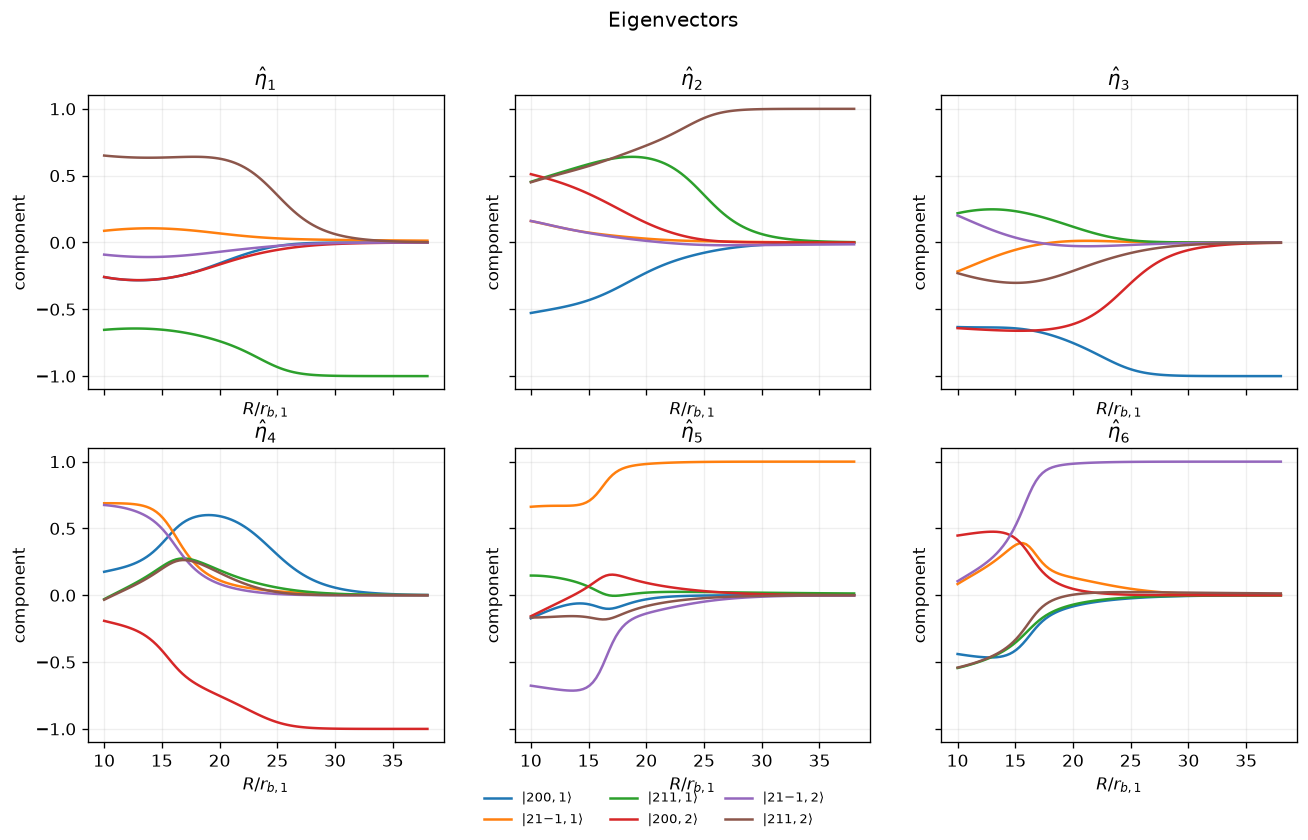

In [5]:
tracked_eigenvalues, aligned_vectors, eigenstate_permutations = track_eigensystem(
    model.eigenvalues, model.eigenvectors
)
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for state, ax in enumerate(axes.flat):
    for component, label in enumerate(basis_labels):
        ax.plot(x, aligned_vectors[:, state, component], label=label)
    ax.set_title(state_labels[state])
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(r'$R/r_{b,1}$')
    ax.set_ylabel('component')
handles, labels = axes.flat[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, fontsize=8)
fig.suptitle('Eigenvectors')
plt.show()

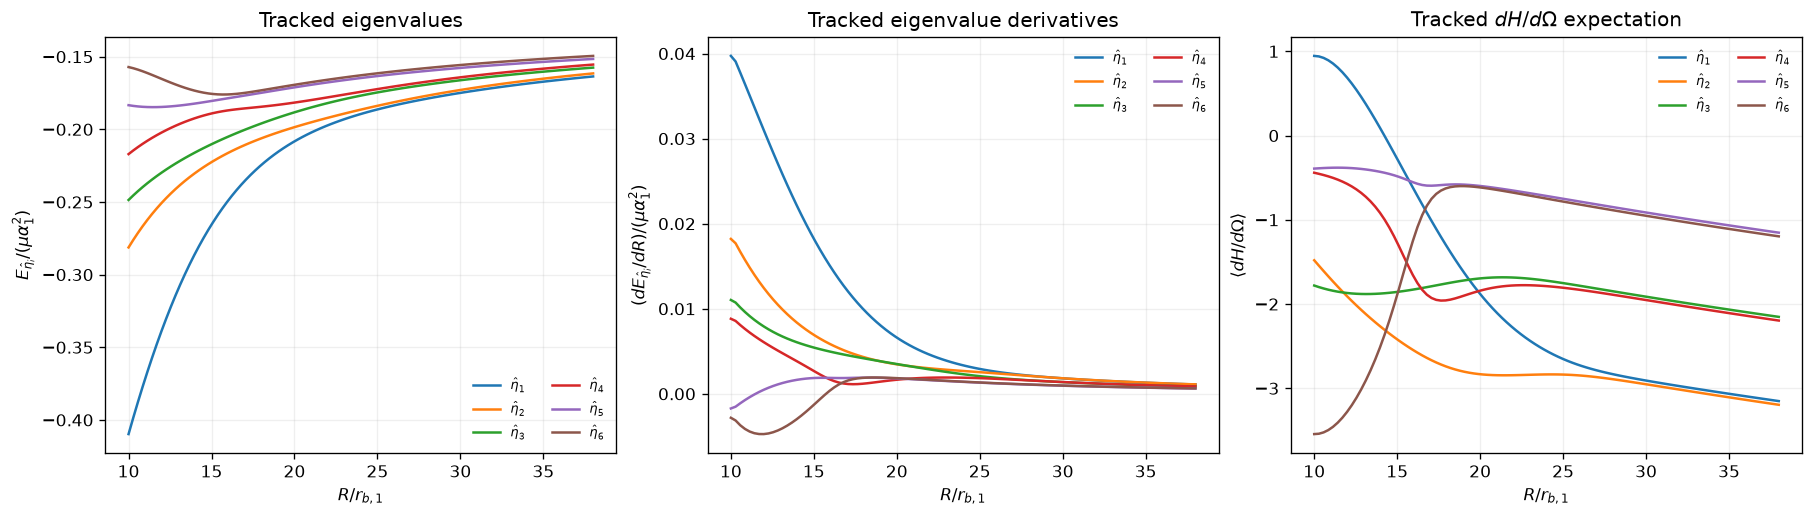

In [6]:
tracked_eigenvalue_derivatives = numerical_derivative(
    tracked_eigenvalues, x
)
tracked_dh_domega_expectation = tracked_expectation(
    aligned_vectors, model.tables.dh_domega
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
plot_state_curves(
    axes[0], tracked_eigenvalues / scale,
    r"$E_{\hat{\eta}_i}/(\mu\alpha_1^2)$",
)
plot_state_curves(
    axes[1], tracked_eigenvalue_derivatives / scale,
    r"$(dE_{\hat{\eta}_i}/dR)/(\mu\alpha_1^2)$",
)
plot_state_curves(
    axes[2], tracked_dh_domega_expectation,
    r"$\langle dH/d\Omega\rangle$",
)
axes[0].set_title("Tracked eigenvalues")
axes[1].set_title("Tracked eigenvalue derivatives")
axes[2].set_title(r"Tracked $dH/d\Omega$ expectation")
plt.show()

## 3. Cloud Centers and GW Frequency

The raw `cloud_center` table also uses instantaneous energy ordering at each separation. Here, `eigenstate_permutations` from Section 2 reorders the cloud centers, and the GW frequency is recomputed from the tracked energy derivatives, $\langle dH/d\Omega\rangle$, and cloud centers. `omega0` is the isolated-binary reference frequency obtained by treating the cloud mass as attached to a black hole.

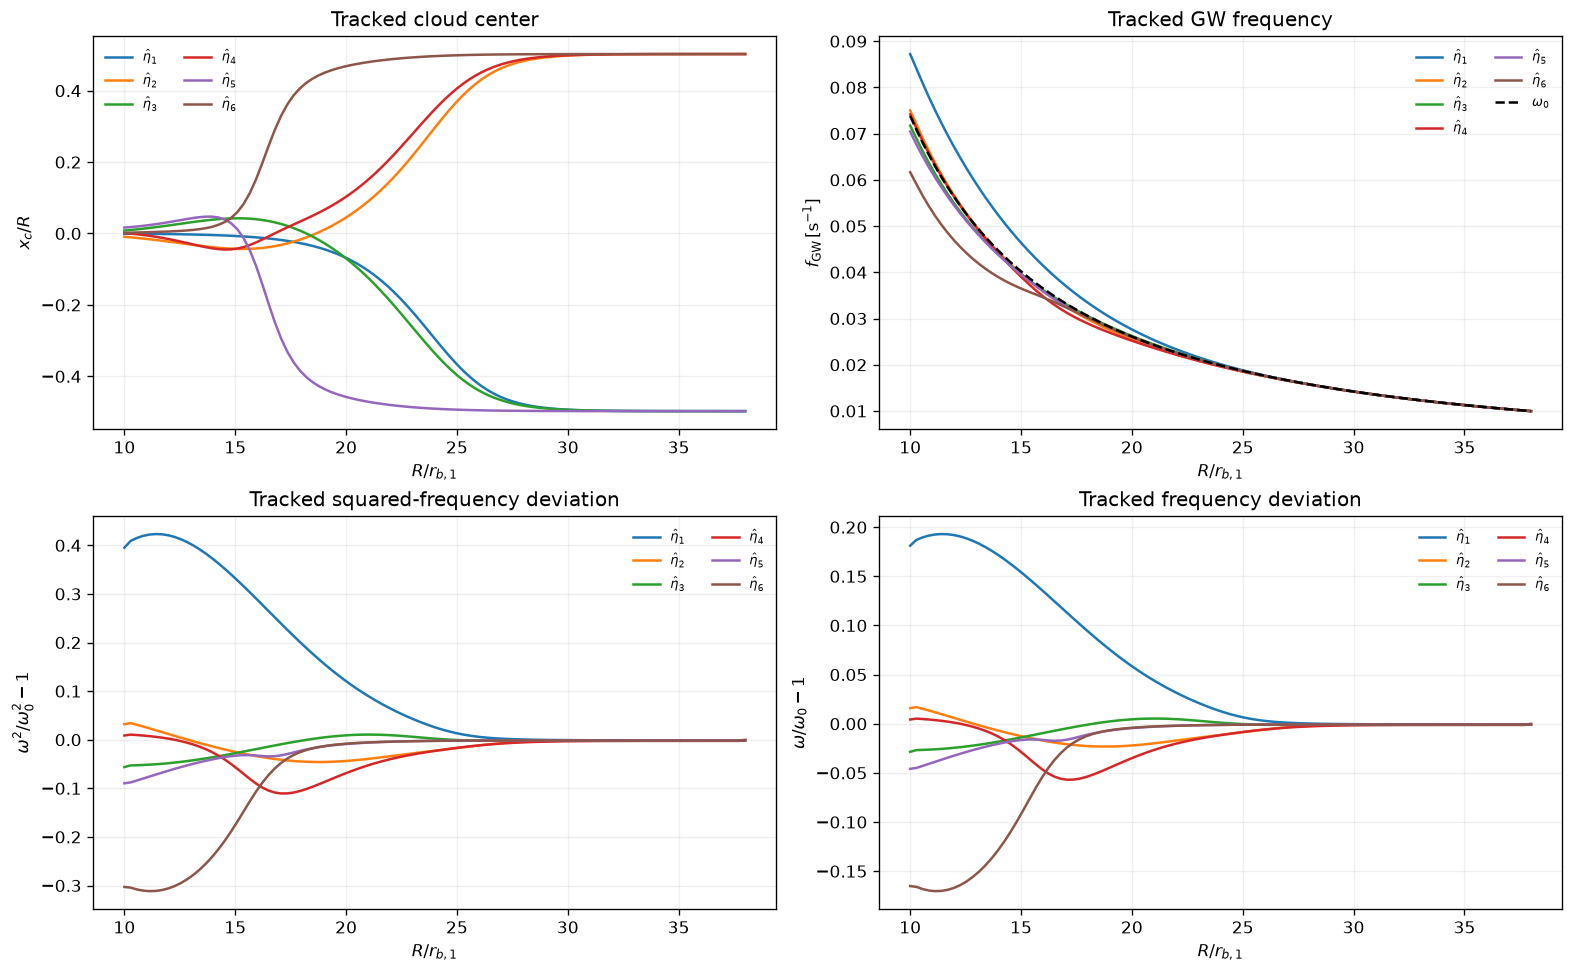

In [7]:
tracked_cloud_center = reorder_state_axis(
    model.tables.cloud_center, eigenstate_permutations
)

p = model.parameters
x_column = x[:, None]
tracked_dedr = tracked_eigenvalue_derivatives + (
    1.5
    * p.energy_scale
    * np.sqrt(1.0 + p.mass_ratio)
    * x_column ** (-1.5)
    * tracked_dh_domega_expectation
    / x_column
)
tracked_x_system = p.cloud_mass * tracked_cloud_center / (
    p.cloud_mass + p.primary_mass + p.secondary_mass
)
tracked_d1 = p.mass_ratio / (1.0 + p.mass_ratio) * x_column + tracked_x_system
tracked_d2 = 1.0 / (1.0 + p.mass_ratio) * x_column - tracked_x_system
tracked_d1_derivative = numerical_derivative(tracked_d1, x)
tracked_d2_derivative = numerical_derivative(tracked_d2, x)

tracked_frequency_squared = (
    p.primary_mass * p.secondary_mass / (x_column**2 * p.bohr_radius_primary)
    + tracked_dedr * (p.cloud_mass / p.boson_mass)
) / (
    (
        p.primary_mass * tracked_d1 * tracked_d1_derivative
        + p.secondary_mass * tracked_d2 * tracked_d2_derivative
    )
    * p.bohr_radius_primary**2
) / np.pi**2
if np.any(tracked_frequency_squared <= 0.0):
    raise FloatingPointError("computed non-positive tracked GW frequency squared")
tracked_frequency = np.sqrt(tracked_frequency_squared)

omega0_squared = isolated_binary_frequency_squared(model)
omega0 = np.sqrt(omega0_squared)
frequency_squared_deviation = tracked_frequency_squared / omega0_squared[:, None] - 1.0
frequency_deviation = tracked_frequency / omega0[:, None] - 1.0

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
plot_state_curves(axes[0, 0], tracked_cloud_center / x[:, None], r"$x_c/R$")
plot_state_curves(
    axes[0, 1], tracked_frequency / PLANCK_TIME_S,
    r"$f_{\rm GW}\,[\mathrm{s}^{-1}]$",
)
axes[0, 1].plot(x, omega0 / PLANCK_TIME_S, "k--", label=r"$\omega_0$")
axes[0, 1].legend(fontsize=8, ncol=2)
plot_state_curves(
    axes[1, 0], frequency_squared_deviation,
    r"$\omega^2/\omega_0^2-1$",
)
plot_state_curves(
    axes[1, 1], frequency_deviation,
    r"$\omega/\omega_0-1$",
)
axes[0, 0].set_title("Tracked cloud center")
axes[0, 1].set_title("Tracked GW frequency")
axes[1, 0].set_title("Tracked squared-frequency deviation")
axes[1, 1].set_title("Tracked frequency deviation")
plt.show()

## 4. Quadrupole Radiation Power

The raw `cloud_quadrupole` table and `model.gr_power` also use instantaneous energy ordering. This section reorders the cloud quadrupoles with the Section 2 permutations and recomputes the mass quadrupoles and radiation power from the tracked cloud centers and GW frequencies. The reference power assigns the cloud mass of the first three tracked states to the primary black hole and that of the final three states to the secondary, matching Mathematica's `OriginalGRPower` definition.

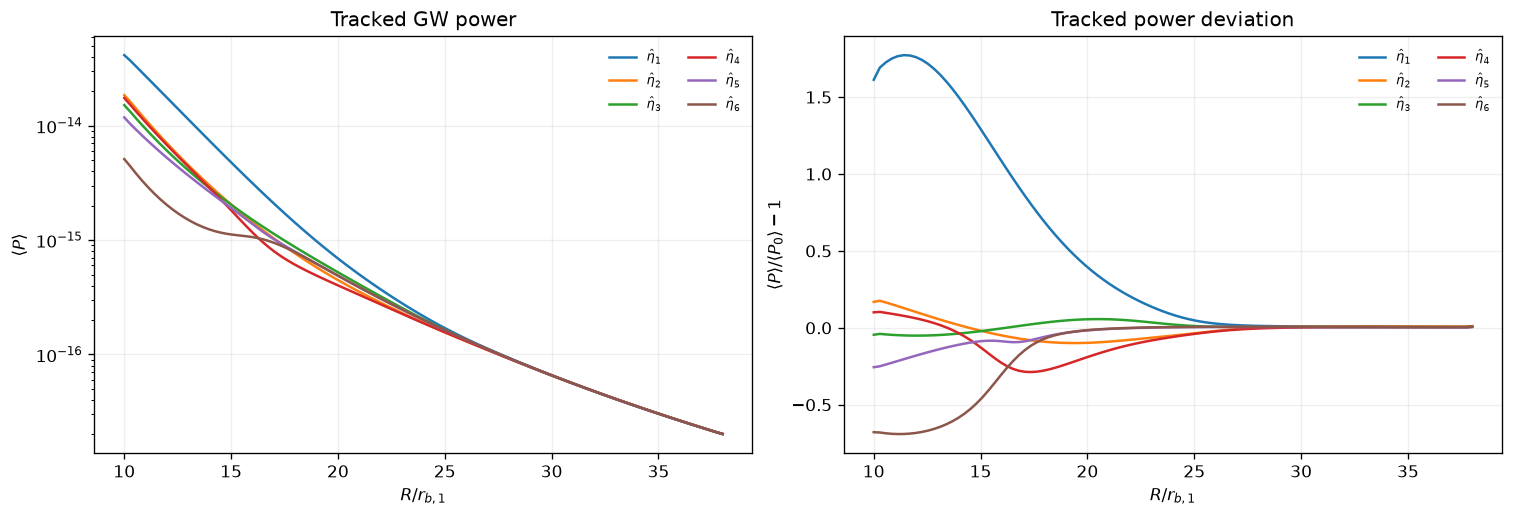

In [8]:
tracked_cloud_quadrupole = reorder_state_axis(
    model.tables.cloud_quadrupole, eigenstate_permutations
)
tracked_q_bbh = (
    p.primary_mass
    * (
        p.mass_ratio / (1.0 + p.mass_ratio) * x_column * p.bohr_radius_primary
        + tracked_x_system * p.bohr_radius_primary
    ) ** 2
    + p.secondary_mass
    * (
        1.0 / (1.0 + p.mass_ratio) * x_column * p.bohr_radius_primary
        - tracked_x_system * p.bohr_radius_primary
    ) ** 2
)
tracked_mass_quadrupole = (
    p.cloud_mass
    * tracked_cloud_quadrupole
    * p.bohr_radius_primary**2
).copy()
tracked_mass_quadrupole[:, :, 0, 0] += tracked_q_bbh

q_tensor = tracked_mass_quadrupole
tracked_power_bracket = (
    16.0 * q_tensor[:, :, 0, 0] ** 2
    + 72.0 * q_tensor[:, :, 0, 1] ** 2
    + q_tensor[:, :, 0, 2] ** 2
    + 8.0 * q_tensor[:, :, 1, 1] ** 2
    - 16.0
    * q_tensor[:, :, 0, 0]
    * (q_tensor[:, :, 0, 1] + q_tensor[:, :, 1, 1])
    + q_tensor[:, :, 1, 2] ** 2
)
tracked_gr_power = (
    (2.0 / 5.0)
    * tracked_power_bracket
    * (np.pi**2 * tracked_frequency_squared) ** 3
)

power0 = isolated_binary_power(model)
power_deviation = tracked_gr_power / power0 - 1.0

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True)
plot_state_curves(axes[0], tracked_gr_power, r"$\langle P\rangle$")
axes[0].set_yscale("log")
plot_state_curves(
    axes[1], power_deviation,
    r"$\langle P\rangle/\langle P_0\rangle-1$",
)
axes[0].set_title("Tracked GW power")
axes[1].set_title("Tracked power deviation")
plt.show()

In [9]:
print("power deviation at the largest separation")
print(power_deviation[-1])

power deviation at the largest separation
[0.00931299 0.01132345 0.00658503 0.00667961 0.0051658  0.00715304]


## 5. Cloud energy in the laboratory frame

The laboratory-frame correction is likewise evaluated with the tracked eigenvectors, and the numerical energy derivative is computed after state reordering. The third plot retains the analytic reference curve `q(2+q) / (2 R^2 (1+q))` used for comparison in Mathematica; the logarithmic plot shows only positive derivatives.

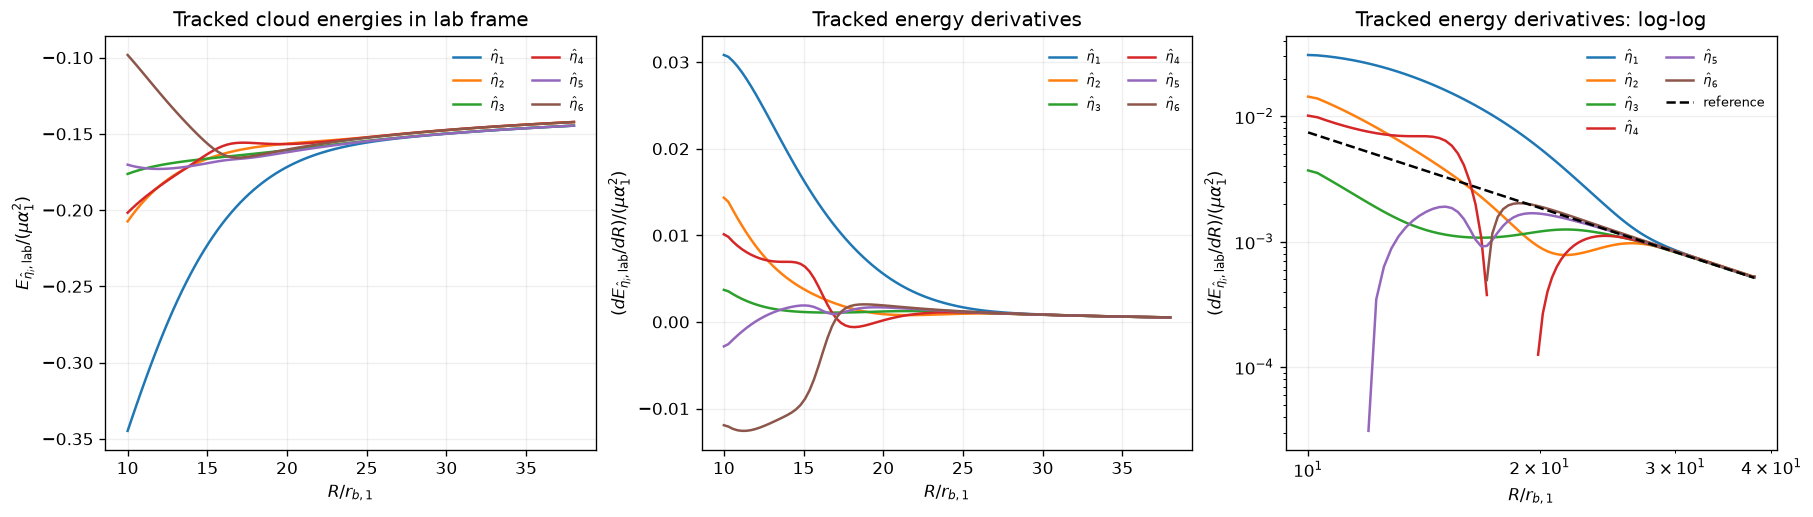

In [10]:
tracked_omega_lz_expectation = tracked_expectation(
    aligned_vectors, model.tables.omega_lz_dimless
)
tracked_cloud_energies_lab = tracked_eigenvalues + (
    tracked_omega_lz_expectation * scale
)
tracked_cloud_energy_derivatives_lab = numerical_derivative(
    tracked_cloud_energies_lab, x
)
cloud_energy = tracked_cloud_energies_lab / scale
cloud_energy_derivative = tracked_cloud_energy_derivatives_lab / scale
derivative_reference = q * (2.0 + q) / (2.0 * x**2 * (1.0 + q))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
plot_state_curves(
    axes[0], cloud_energy,
    r"$E_{\hat{\eta}_i,\rm lab}/(\mu\alpha_1^2)$",
)
plot_state_curves(
    axes[1], cloud_energy_derivative,
    r"$(dE_{\hat{\eta}_i,\rm lab}/dR)/(\mu\alpha_1^2)$",
)
positive_derivative = np.where(
    cloud_energy_derivative > 0.0, cloud_energy_derivative, np.nan
)
plot_state_curves(
    axes[2], positive_derivative,
    r"$(dE_{\hat{\eta}_i,\rm lab}/dR)/(\mu\alpha_1^2)$",
    yscale="log",
)
axes[2].plot(x, derivative_reference, "k--", label="reference")
axes[2].set_xscale("log")
axes[2].legend(fontsize=8, ncol=2)
axes[0].set_title("Tracked cloud energies in lab frame")
axes[1].set_title("Tracked energy derivatives")
axes[2].set_title("Tracked energy derivatives: log-log")
plt.show()

## 6. Orbital Evolution and Chirp Mass for Six Tracked Eigenstates

First construct the total system energy from the tracked cloud energies, cloud centers, GW frequencies, and powers, then inject these continuous branches into a `GMModel` instance for `evolve`. For each state, the solver integrates `dE/dR * dR/dt = -P_GW`; if `dE/dR = 0` occurs inside a stable branch, evolution stops before the singularity.

In [11]:
tracked_rho1 = p.mass_ratio / (1.0 + p.mass_ratio) * x_column
tracked_rho2 = 1.0 / (1.0 + p.mass_ratio) * x_column
tracked_system_center = (
    p.cloud_mass * tracked_cloud_center
    - p.primary_mass * tracked_rho1
    + p.secondary_mass * tracked_rho2
) / (p.cloud_mass + p.primary_mass + p.secondary_mass)
tracked_system_d1 = (
    p.mass_ratio / (1.0 + p.mass_ratio) * x_column + tracked_system_center
)
tracked_system_d2 = (
    1.0 / (1.0 + p.mass_ratio) * x_column - tracked_system_center
)
tracked_system_energies_lab = (
    (p.cloud_mass / p.boson_mass) * tracked_cloud_energies_lab
    - p.primary_mass * p.secondary_mass
    / (x_column * p.bohr_radius_primary)
    + 0.5 * p.primary_mass * (np.pi**2 * tracked_frequency_squared)
    * (tracked_system_d1 * p.bohr_radius_primary) ** 2
    + 0.5 * p.secondary_mass * (np.pi**2 * tracked_frequency_squared)
    * (tracked_system_d2 * p.bohr_radius_primary) ** 2
)

# Seed cached observables so GMModel.evolve operates entirely on tracked branches.
tracked_model = GMModel(parameters, model.tables)
tracked_model.__dict__.update({
    "eigenvalues": tracked_eigenvalues,
    "eigenvectors": aligned_vectors,
    "eigenvalue_derivatives": tracked_eigenvalue_derivatives,
    "dh_domega_expectation": tracked_dh_domega_expectation,
    "gw_frequency_squared": tracked_frequency_squared,
    "gw_frequency": tracked_frequency,
    "mass_quadrupole": tracked_mass_quadrupole,
    "gr_power": tracked_gr_power,
    "cloud_energies_lab": tracked_cloud_energies_lab,
    "cloud_energy_derivatives_lab": tracked_cloud_energy_derivatives_lab,
    "system_energies_lab": tracked_system_energies_lab,
})

evolutions = [
    tracked_model.evolve(state=state, samples=evolution_samples)
    for state in range(6)
]
[(item.state, item.time_years[-1], item.separation[-1]) for item in evolutions]

[(0, np.float64(9.208746525658382), np.float64(10.282828282828302)),
 (1, np.float64(10.830555084122905), np.float64(10.282828282828294)),
 (2, np.float64(10.31925253459626), np.float64(10.282828282828268)),
 (3, np.float64(11.242777621172886), np.float64(10.282828282828282)),
 (4, np.float64(10.583296628930174), np.float64(10.282828282828259)),
 (5, np.float64(11.292924650369358), np.float64(10.282828282828268))]

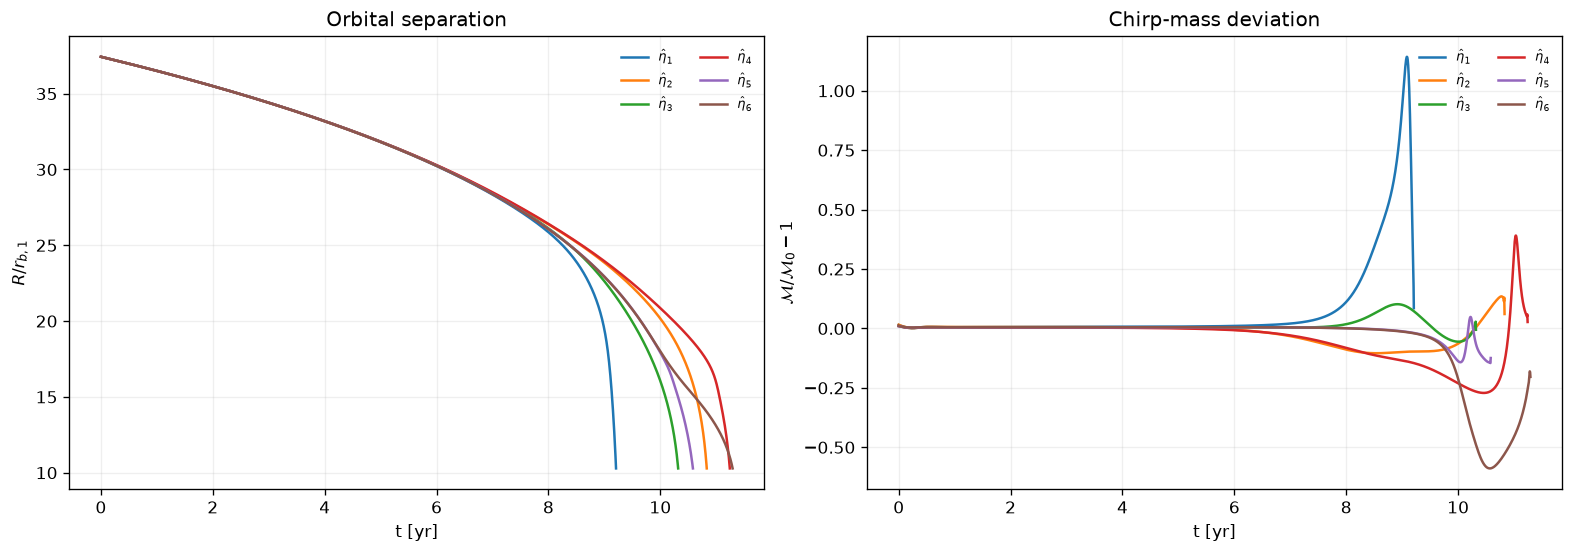

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for evolution, label in zip(evolutions, state_labels):
    axes[0].plot(evolution.time_years, evolution.separation, label=label)
    axes[1].plot(evolution.time_years, evolution.chirp_deviation, label=label)
axes[0].set(xlabel='t [yr]', ylabel=r'$R/r_{b,1}$', title='Orbital separation')
axes[1].set(
    xlabel='t [yr]',
    ylabel=r'$\mathcal{M}/\mathcal{M}_0-1$',
    title='Chirp-mass deviation',
)
for ax in axes:
    ax.legend(fontsize=8, ncol=2)
plt.show()

In [13]:
print('Eigenvector 1 chirp-mass min deviation:')
print(np.min(evolutions[0].chirp_deviation))

Eigenvector 1 chirp-mass min deviation:
0.002140749090521643


## 7. Non-Hermitian eigensystem with superradiant growth widths

The non-Hermitian matrix eigenvalues are also sorted independently at every separation. Adjacent maximum-overlap tracking is applied again to the complex eigenvectors so that real energies and imaginary growth/decay widths share continuous state labels.

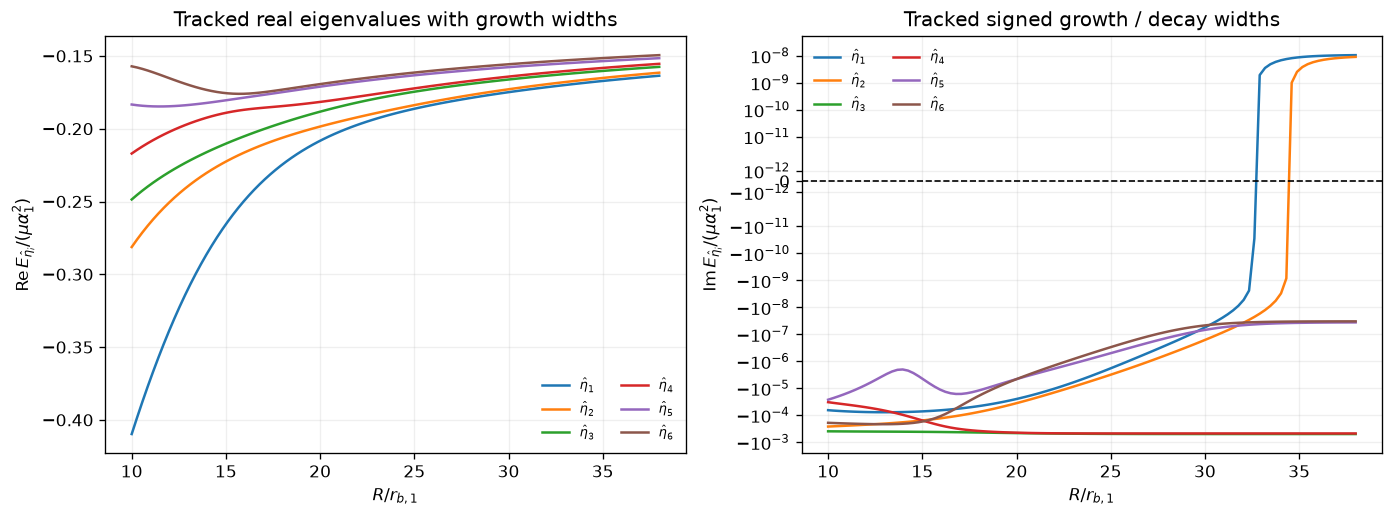

In [14]:
growth_values, growth_vectors = model.eigensystem_with_growth(
    spin_primary=1.0, spin_secondary=1.0
)
tracked_growth_values, tracked_growth_vectors, growth_permutations = (
    track_eigensystem(growth_values, growth_vectors)
)
tracked_growth_values = tracked_growth_values / scale

fig, growth_axes = plt.subplots(
    1, 2, figsize=(11.5, 4.2), constrained_layout=True
)
growth_imaginary = tracked_growth_values.imag
nonzero_growth_imaginary = np.abs(
    growth_imaginary[np.nonzero(growth_imaginary)]
)
growth_linthresh = (
    0.1 * float(np.min(nonzero_growth_imaginary))
    if nonzero_growth_imaginary.size
    else 1.0e-30
)
for state, label in enumerate(state_labels):
    growth_axes[0].plot(x, tracked_growth_values[:, state].real, label=label)
    growth_axes[1].plot(
        x, growth_imaginary[:, state], label=label
    )
growth_axes[0].set(
    xlabel=r"$R/r_{b,1}$",
    ylabel=r"$\mathrm{Re}\,E_{\hat{\eta}_i}/(\mu\alpha_1^2)$",
    title="Tracked real eigenvalues with growth widths",
)
growth_axes[1].set(
    xlabel=r"$R/r_{b,1}$",
    ylabel=r"$\mathrm{Im}\,E_{\hat{\eta}_i}/(\mu\alpha_1^2)$",
    title="Tracked signed growth / decay widths",
)
growth_axes[1].set_yscale("symlog", linthresh=growth_linthresh)
growth_axes[1].axhline(
    0.0, color="black", linestyle="--", linewidth=1.0
)
for ax in growth_axes:
    ax.legend(fontsize=8, ncol=2)
plt.show()

## 8. Signal characteristic strain before the LISA noise model

This section reproduces the `dE/df`, GM characteristic strain, isolated-BBH characteristic strain, and monochromatic amplitude defined before the boundary in the original notebook. The selected `strain_state` uses the tracked GW frequency and total system energy, so it does not switch physical states at level crossings.

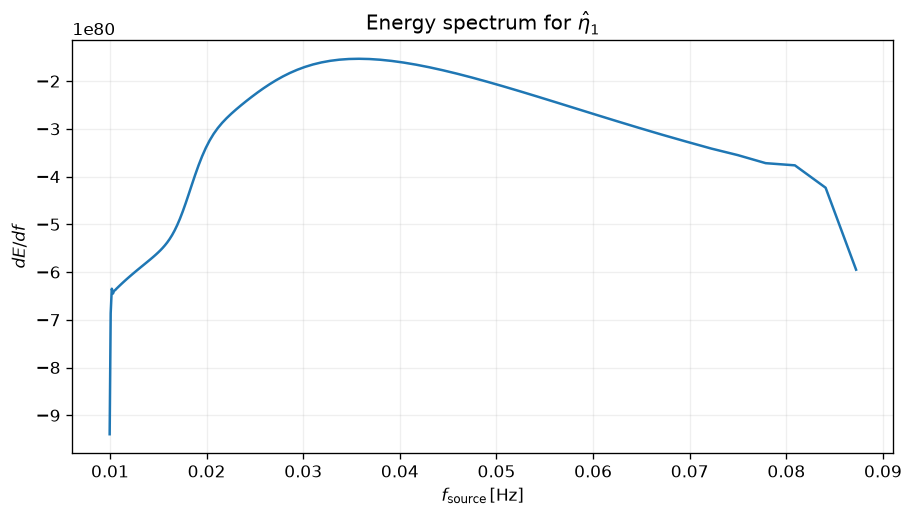

In [15]:
if strain_state not in range(6):
    raise ValueError('strain_state must be in range(6)')

frequency_planck = tracked_frequency[:, strain_state]
system_energy = tracked_system_energies_lab[:, strain_state]
energy_spline = CubicSpline(x, system_energy)
frequency_spline = CubicSpline(x, frequency_planck)
denergy_dfrequency = energy_spline.derivative()(x) / frequency_spline.derivative()(x)

# Build dE/df as a single-valued interpolation on the sampled frequency branch.
order = np.argsort(frequency_planck)
sorted_frequency, unique_indices = np.unique(frequency_planck[order], return_index=True)
sorted_denergy_dfrequency = denergy_dfrequency[order][unique_indices]
denergy_dfrequency_spline = CubicSpline(sorted_frequency, sorted_denergy_dfrequency)

source_frequency_hz = sorted_frequency / PLANCK_TIME_S
fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
ax.plot(source_frequency_hz, sorted_denergy_dfrequency)
ax.set(xlabel=r'$f_{\rm source}\,[\mathrm{Hz}]$', ylabel=r'$dE/df$')
ax.set_title(rf'Energy spectrum for {state_labels[strain_state]}')
plt.show()

detector_frequency_hz = np.linspace(
    source_frequency_hz[0] / (1.0 + redshift),
    source_frequency_hz[-1] / (1.0 + redshift),
    800,
)
source_frequency_planck = (
    (1.0 + redshift) * detector_frequency_hz * PLANCK_TIME_S
)
distance = luminosity_distance_planck(redshift)
minus_denergy_dfrequency = -denergy_dfrequency_spline(source_frequency_planck)
if np.any(minus_denergy_dfrequency <= 0.0):
    raise FloatingPointError('-dE/df must remain positive on the selected branch')

hc_gm = np.sqrt(
    2.0 * (1.0 + redshift) ** 2
    / (np.pi**2 * distance**2)
    * minus_denergy_dfrequency
)
chirp_mass = (
    (parameters.primary_mass * parameters.secondary_mass) ** (3.0 / 5.0)
    / (parameters.primary_mass + parameters.secondary_mass) ** (1.0 / 5.0)
)
hc_bbh = np.sqrt(
    2.0 / (np.pi**2 * distance**2)
    * np.pi ** (2.0 / 3.0) / 3.0
    * ((1.0 + redshift) * chirp_mass) ** (5.0 / 3.0)
    * (detector_frequency_hz * PLANCK_TIME_S) ** (-1.0 / 3.0)
)
monochromatic_amplitude = (
    4.0 / distance
    * ((1.0 + redshift) * chirp_mass) ** (5.0 / 3.0)
    * (np.pi * PLANCK_TIME_S * detector_frequency_hz) ** (2.0 / 3.0)
)

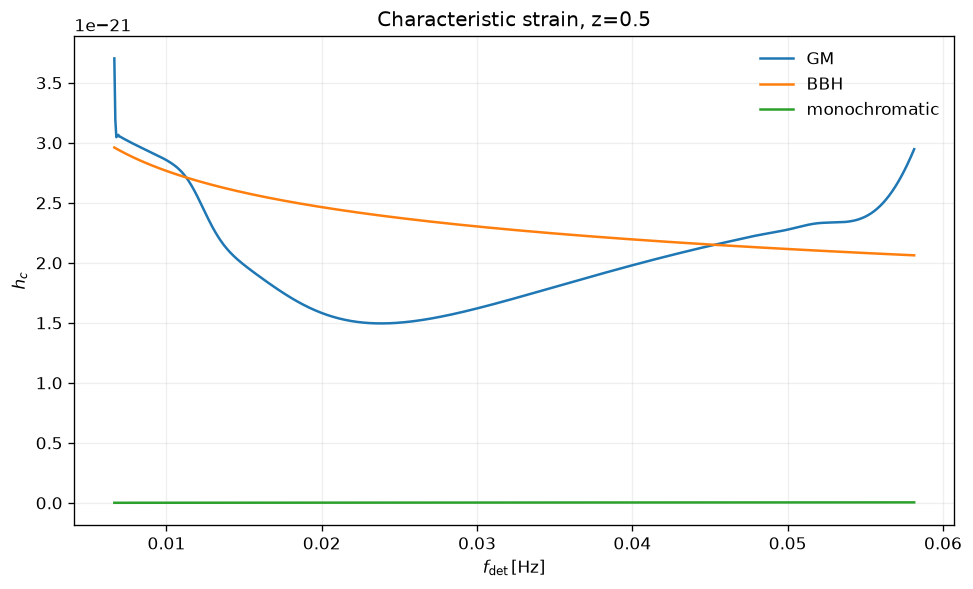

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
ax.plot(detector_frequency_hz, hc_gm, label='GM')
ax.plot(detector_frequency_hz, hc_bbh, label='BBH')
ax.plot(detector_frequency_hz, monochromatic_amplitude, label='monochromatic')
ax.set(xlabel=r'$f_{\rm det}\,[\mathrm{Hz}]$', ylabel=r'$h_c$')
ax.set_title(f'Characteristic strain, z={redshift:g}')
ax.legend()
plt.show()

## Stopping point

This is all computable content before the **LISA noise model** heading in `GMMainPlot_v2.0.nb`. Compressed static graphics mistakenly stored as Input in the Mathematica file were not copied; the corresponding physical curves are regenerated by the Python cells above.